In [1]:
%matplotlib inline

import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)

import matplotlib.pyplot as plt
from IPython.display import display

import torch
import numpy as np
from PIL import Image

from src.optics.asm import asm
from src.phase_retrieval import retrieve_phase
from src.vis import img_crop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_intensity_path = "smile.png"
phase_profile_path = None # phase_profile_path = "demo2_smile_phase_profile.npy"

img = Image.open(target_intensity_path).convert("L")  # grayscale
target_intensity = torch.from_numpy(np.array(img)).to(device=device, dtype=torch.float32)
target_intensity = target_intensity / 255.0

In [2]:
wvln_um = 0.7

# hologram setup
slm_pixel_pitch = 0.0063
slm_res = target_intensity.shape[0]
slm_radius = slm_res // 2 * slm_pixel_pitch

xy_slm = torch.arange(-slm_radius, slm_radius, slm_pixel_pitch, device=device)
X_slm, Y_slm = torch.meshgrid(xy_slm, xy_slm, indexing='xy')

# sensor
f_num = 4
d_sensor = f_num * slm_radius

if phase_profile_path is None:
    slm_phase_profile, _, loss = retrieve_phase(
        target_intensity=target_intensity,
        wavelength_um=wvln_um,
        dx_mm=slm_pixel_pitch,
        dy_mm=slm_pixel_pitch,
        dist_mm=d_sensor,
        mask_radius=slm_res//2,
        max_iter=200,
        learning_rate=0.1,
        device=device,
    )
    slm_phase_profile = slm_phase_profile.to(device)
    np.save("demo2_smile_phase_profile.npy", slm_phase_profile.detach().cpu().numpy())
else:
    slm_phase_profile = torch.from_numpy(np.load(phase_profile_path)).to(device)

slm_amplitude = ((X_slm**2 + Y_slm**2) < slm_radius**2).to(device)
slm_profile = slm_amplitude * torch.exp(1j * slm_phase_profile)

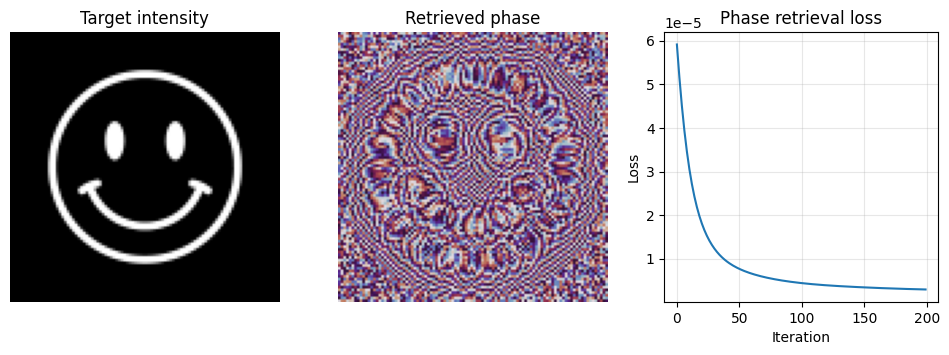

In [3]:
target_np = target_intensity.detach().float().cpu().numpy()
phase_np = slm_phase_profile.detach().float().cpu().numpy()

# wrap phase to [-pi, pi] for cleaner visualization
phase_wrapped = np.angle(np.exp(1j * phase_np))

fig, axs = plt.subplots(1, 3, figsize=(12, 3.5))

axs[0].imshow(target_np, cmap="gray")
axs[0].set_title("Target intensity")
axs[0].axis("off")

im = axs[1].imshow(phase_wrapped, cmap="twilight", vmin=-np.pi, vmax=np.pi)
axs[1].set_title("Retrieved phase")
axs[1].axis("off")

if torch.is_tensor(loss):
    loss_np = loss.detach().cpu().numpy()
else:
    loss_np = np.asarray(loss)

axs[2].plot(loss_np)
axs[2].set_title("Phase retrieval loss")
axs[2].set_xlabel("Iteration")
axs[2].set_ylabel("Loss")
axs[2].grid(True, alpha=0.3)

display(fig)
plt.close(fig)

Text(0.5, 1.0, 'ASM intensity')

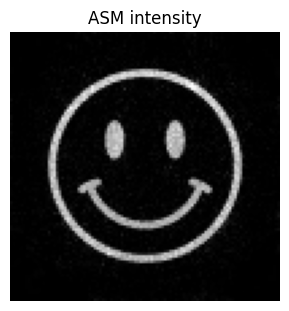

In [4]:
sensor_field = asm(
    slm_profile, 
    z_mm=d_sensor, 
    dx_mm=slm_pixel_pitch, 
    dy_mm=slm_pixel_pitch, 
    wavelength_mm=wvln_um*1e-3, 
    padding=True, 
    device=device)
psf_asm = sensor_field.abs()**2

plt.figure(figsize=(3.5, 3.5))
plt.imshow(psf_asm.cpu().numpy(), cmap="gray")
plt.axis("off")
plt.title("ASM intensity")